In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.features import shapes
from shapely.geometry import shape
import os

data_dir = "../data/aster/"

def load_band(band_num):
    pattern = f"TIR_B{band_num}.tif"
    path = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if pattern in f][0]
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        profile = src.profile
        transform = src.transform
        crs = src.crs
    data[data == 0] = np.nan
    return data, profile, transform, crs

def band_ratio(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(b != 0, a / b, np.nan)

b10, profile, transform, crs = load_band(10)
b11, _, _, _ = load_band(11)
b12, _, _, _ = load_band(12)
b13, _, _, _ = load_band(13)
b14, _, _, _ = load_band(14)

silica    = band_ratio(b13, b14)
carbonate = band_ratio(b13, b12)
mafic     = band_ratio(b12, b13)

print("Ready")
print(f"CRS: {crs}")
print(f"Transform: {transform}")

Ready
CRS: EPSG:32611
Transform: | 90.00, 0.00, 397890.00|
| 0.00,-90.00, 4640400.00|
| 0.00, 0.00, 1.00|


In [2]:
def classify(ratio, low_pct=70, high_pct=90):
    low  = np.nanpercentile(ratio, low_pct)
    high = np.nanpercentile(ratio, high_pct)
    classes = np.zeros_like(ratio, dtype=np.uint8)
    classes[ratio >= low]  = 1  # moderate anomaly
    classes[ratio >= high] = 2  # strong anomaly
    classes[np.isnan(ratio)] = 0
    return classes, low, high

silica_cls,    s_lo, s_hi = classify(silica)
carbonate_cls, c_lo, c_hi = classify(carbonate)
mafic_cls,     m_lo, m_hi = classify(mafic)

# Combined score 0-6
combined = silica_cls.astype(np.uint8) + carbonate_cls.astype(np.uint8) + mafic_cls.astype(np.uint8)

print(f"Silica    thresholds: moderate={s_lo:.4f}, strong={s_hi:.4f}")
print(f"Carbonate thresholds: moderate={c_lo:.4f}, strong={c_hi:.4f}")
print(f"Mafic     thresholds: moderate={m_lo:.4f}, strong={m_hi:.4f}")
print(f"\nCombined score distribution:")
for v in range(7):
    count = np.sum(combined == v)
    pct = count / combined.size * 100
    print(f"  score {v}: {count:6d} pixels ({pct:.1f}%)")

Silica    thresholds: moderate=0.9768, strong=0.9800
Carbonate thresholds: moderate=1.1450, strong=1.1626
Mafic     thresholds: moderate=0.8824, strong=0.8881

Combined score distribution:
  score 0: 471043 pixels (58.0%)
  score 1: 176814 pixels (21.8%)
  score 2: 107552 pixels (13.2%)
  score 3:  33684 pixels (4.1%)
  score 4:  23715 pixels (2.9%)
  score 5:      0 pixels (0.0%)
  score 6:      0 pixels (0.0%)


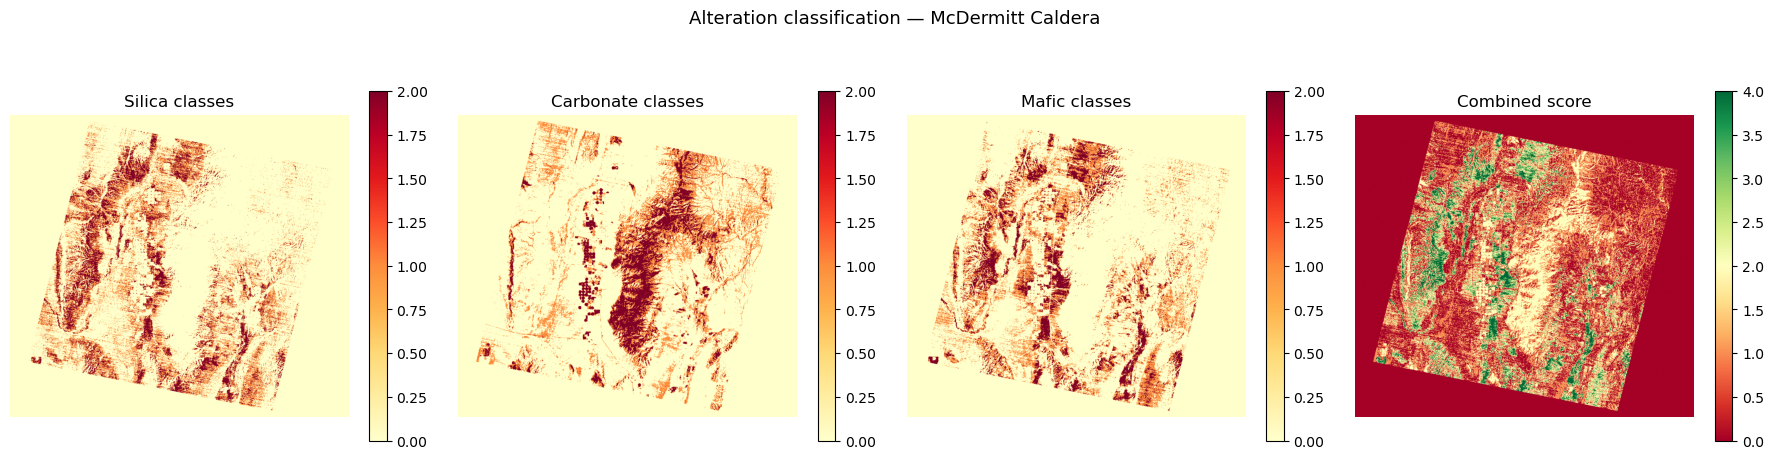


Vectorized 6938 strong anomaly zones
Total anomaly area: 464.9 km²
Largest zone: 38.3 km²


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

cmaps = ['YlOrRd', 'YlOrRd', 'YlOrRd', 'RdYlGn']
titles = ['Silica classes', 'Carbonate classes', 'Mafic classes', 'Combined score']
arrays = [silica_cls, carbonate_cls, mafic_cls, combined]

for ax, arr, title, cmap in zip(axes, arrays, titles, cmaps):
    im = ax.imshow(arr, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Alteration classification — McDermitt Caldera', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/02_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# Vectorize strong anomalies (combined score >= 3)
strong_mask = (combined >= 3).astype(np.uint8)

geoms = []
for geom, val in shapes(strong_mask, transform=transform):
    if val == 1:
        geoms.append(shape(geom))

zones = gpd.GeoDataFrame(geometry=geoms, crs=crs)
zones['area_km2'] = zones.geometry.area / 1e6

print(f"\nVectorized {len(zones)} strong anomaly zones")
print(f"Total anomaly area: {zones['area_km2'].sum():.1f} km²")
print(f"Largest zone: {zones['area_km2'].max():.1f} km²")

In [4]:
os.makedirs("../data/vectors", exist_ok=True)
zones.to_file("../data/vectors/strong_anomaly_zones.geojson", driver="GeoJSON")
print(f"Saved {len(zones)} zones to data/vectors/strong_anomaly_zones.geojson")

# Quick summary stats
zones_sorted = zones.sort_values('area_km2', ascending=False)
print(f"\nTop 10 largest anomaly zones:")
print(zones_sorted[['area_km2']].head(10).to_string())

Saved 6938 zones to data/vectors/strong_anomaly_zones.geojson

Top 10 largest anomaly zones:
      area_km2
3581   38.3130
822    14.2155
820    12.9924
5141   12.9681
3453   11.4858
5660   10.3113
6626    9.5094
463     8.3268
6120    8.1324
2775    7.6221
